# 02 · Feature engineering, validation design and model benchmark

This notebook walks through the modelling decisions and reproduces the headline comparison. The full experiment (time-series cross-validation, imbalance treatments, feature ablation, tuning) is run by `fraud-detection run --tune`; its outputs are loaded from `reports/metrics/results.json` where re-running would take minutes rather than seconds.

In [1]:
import json, sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
from IPython.display import Image, display, Markdown
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40); pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
FIG = ROOT / "reports" / "figures"
import tempfile
FIG_NB = Path(tempfile.mkdtemp())  # figures drawn in this notebook; the pipeline's own figures live in reports/figures
sys.path.insert(0, str(ROOT / "src"))
from fraud_detection.config import PipelineConfig, SplitConfig, CostAssumptions
from fraud_detection.data import load_raw, profile, clean
from fraud_detection.features import build_features, feature_columns, NUMERIC_FEATURES, CATEGORICAL_FEATURES
from fraud_detection import plots
DATA = ROOT / "data" / "fraud.csv"

## 1. Point-in-time features

Every history feature for a transaction at step *t* uses only steps **strictly before** *t*. Transactions inside one step have no ordering, so excluding the current step entirely is the conservative choice and mirrors a batch feature store refreshed each step. No feature uses the label.

`scripts/check_features.py` guards this on the real data: a brute-force recomputation of a sample, features for steps < *t* identical with and without later data, and no change when every label is flipped. History features are rolling windows and shares rather than cumulative counts, so none of them drifts with calendar time by construction.

**Missing values.** The raw file has none. The engineered history features are missing by design for a customer's first transaction (no baseline yet); the boosted models handle missing values natively, the linear, forest and neural-network models get median imputation inside their pipelines, and the `cust_is_new` flag keeps the information that there was no history.

In [2]:
df = build_features(clean(load_raw(DATA)))
print(df.shape)
print("numeric:", NUMERIC_FEATURES)
print("categorical:", CATEGORICAL_FEATURES)
df[["step", "customer", "category", "amount", "cust_prev_mean_amount", "amount_over_cust_mean", "cust_n_last_7", "cust_first_time_merchant", "cust_merch_prev_share", "merch_share_last_24", "merch_mean_amount_last_24", "amount_over_cat_mean"]].sample(8, random_state=1)

(594643, 35)
numeric: ['amount', 'log_amount', 'hour_of_day', 'day_of_week', 'cust_prev_mean_amount', 'cust_prev_std_amount', 'cust_prev_max_amount', 'amount_over_cust_mean', 'amount_z_cust', 'amount_over_cust_max', 'cust_steps_since_last', 'cust_n_last_7', 'cust_n_last_24', 'cust_amount_last_7', 'cust_cat_prev_share', 'cust_merch_prev_share', 'cust_first_time_category', 'cust_first_time_merchant', 'cust_is_new', 'merch_share_last_24', 'merch_mean_amount_last_24', 'amount_over_merch_mean', 'cat_mean_amount_last_24', 'amount_over_cat_mean']
categorical: ['category', 'merchant', 'age', 'gender']


,step,customer,category,amount,cust_prev_mean_amount,amount_over_cust_mean,cust_n_last_7,cust_first_time_merchant,cust_merch_prev_share,merch_share_last_24,merch_mean_amount_last_24,amount_over_cat_mean
437607,137,C206142588,es_transportation,12.1800,30.7381,0.3838,6.0000,0.0000,0.6641,0.5888,26.8435,0.4367
415046,131,C1629765833,es_food,53.5000,30.5648,1.6949,7.0000,0.0000,0.0312,0.0505,37.4439,1.3916
467853,145,C1850870588,es_transportation,27.1200,36.2073,0.7289,6.0000,0.0000,0.1553,0.6013,26.8486,0.9721
76450,28,C179196508,es_transportation,23.4300,44.3032,0.5172,7.0000,0.0000,0.8214,0.5798,27.0606,0.8356
84492,31,C1264836741,es_transportation,38.1200,21.4886,1.6951,7.0000,0.0000,0.9643,0.5638,27.0784,1.3596
32509,12,C2049000934,es_transportation,38.8400,31.5300,1.1940,7.0000,0.0000,0.9091,0.6399,26.9957,1.3866
105923,38,C1867566140,es_transportation,3.8500,84.5814,0.0450,4.0000,0.0000,0.1429,0.5290,26.9751,0.1377
167039,58,C229665572,es_transportation,2.8300,26.0251,0.1047,7.0000,0.0000,0.9245,0.4484,26.9257,0.1013


## 2. Temporal split and expanding-window folds

Fraud models score the *future*, so the hold-out is the last 20% of steps (144-179). Inside the training window, three expanding-window folds validate on steps 96-111, 112-127 and 128-143. Thresholds are chosen on out-of-fold predictions and applied unchanged to the hold-out.

In [3]:
from fraud_detection.split import temporal_split, time_series_folds
cfg = PipelineConfig()
train, test = temporal_split(df, cfg.split)
print(f"train: {len(train):,} rows, steps {train.step.min()}-{train.step.max()}, fraud {train.fraud.sum():,}")
print(f"test : {len(test):,} rows, steps {test.step.min()}-{test.step.max()}, fraud {test.fraud.sum():,}")
for i, (tr, va) in enumerate(time_series_folds(train.step, cfg.split), 1):
    print(f"fold {i}: train steps < {train.step.iloc[va].min()}, validate steps {train.step.iloc[va].min()}-{train.step.iloc[va].max()} ({len(va):,} rows)")

train: 461,412 rows, steps 0-143, fraud 5,760
test : 133,231 rows, steps 144-179, fraud 1,440
fold 1: train steps < 96, validate steps 96-111 (55,612 rows)
fold 2: train steps < 112, validate steps 112-127 (56,896 rows)
fold 3: train steps < 128, validate steps 128-143 (57,906 rows)


## 3. Six model families on the temporal split

A transparent depth-3 tree (eight rules on amount and category) is the baseline a fraud team could deploy today. Logistic regression and a random forest are the classical comparators, a small neural network covers the option the brief lists, and LightGBM and XGBoost are the boosting candidates. All but the network use class weighting for the 1:79 imbalance; every model is thresholded on validation.

In [4]:
import time
from fraud_detection.models import MODEL_SPECS, make_model, positive_scale
from fraud_detection.evaluate import ranking_metrics
feats = feature_columns(include_protected=True, include_time=True)
spw = positive_scale(train.fraud)
preds, rows = {}, []
for key, spec in MODEL_SPECS.items():
    t0 = time.time()
    m = make_model(key, feats, spw, quick=True).fit(train[feats], train.fraud)
    preds[key] = m.predict_proba(test[feats])[:, 1]
    r = ranking_metrics(test.fraud.to_numpy(), preds[key])
    rows.append({"model": spec.name, "roc_auc": r["roc_auc"], "average_precision": r["average_precision"], "best_f1": r["best_f1"], "recall@top1%": r["recall_at_top_1pct"], "precision@top1%": r["precision_at_top_1pct"], "fit_s": time.time() - t0})
pd.DataFrame(rows).set_index("model")

,roc_auc,average_precision,best_f1,recall@top1%,precision@top1%,fit_s
model,,,,,,
Rules baseline (depth-4 tree),0.9852,0.7214,0.7099,0.6597,0.7132,0.3052
Logistic regression,0.9989,0.9283,0.8547,0.8167,0.8829,2.5478
Random forest,0.9981,0.9355,0.8664,0.8319,0.8994,2.8113
Neural network (MLP),0.9993,0.9554,0.8894,0.8521,0.9212,4.2997
LightGBM,0.9993,0.9559,0.8890,0.8528,0.9219,3.7276
XGBoost,0.9993,0.9550,0.8848,0.8493,0.9182,1.6160


Quick-mode models above (fewer trees) are for illustration; the pipeline uses full-size models with three-fold time-series CV. ROC-AUC exceeds 0.98 for every model including the rules baseline, so it does not discriminate between candidates. Average precision does.

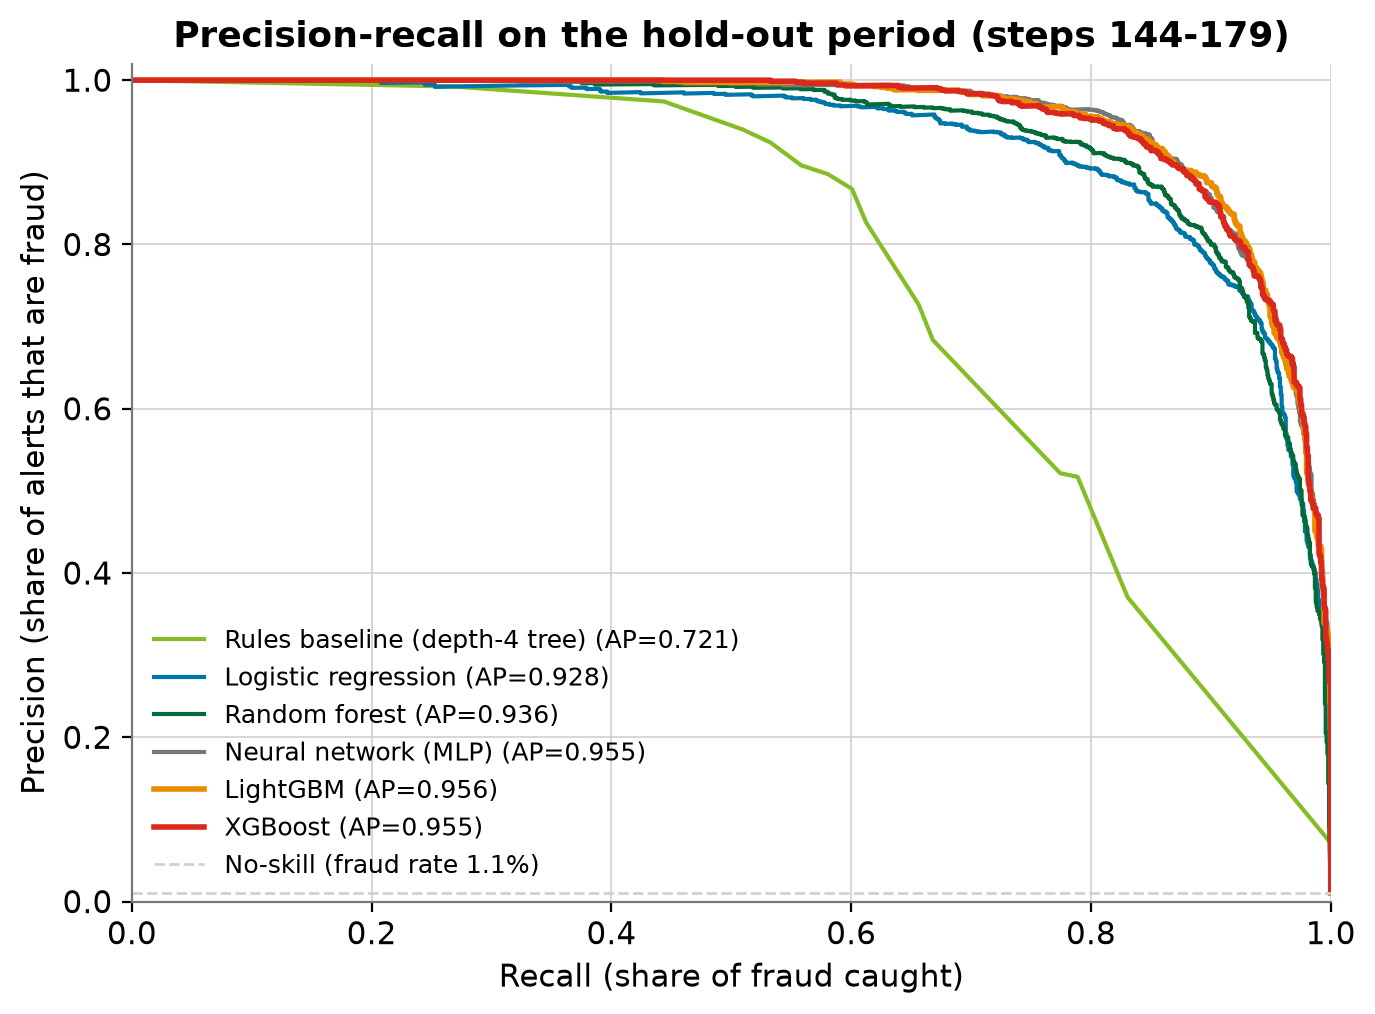

In [5]:
names = {k: v.name for k, v in MODEL_SPECS.items()}
display(Image(plots.pr_curves(preds, test.fraud.to_numpy(), FIG_NB / "pr_curves.png", names)))

## 4. Full experiment results (from the pipeline)

Cross-validated and hold-out metrics for full-size models, plus the imbalance and ablation experiments scored on the last validation fold (never on the hold-out).

In [6]:
R = json.loads((ROOT / "reports" / "metrics" / "results.json").read_text())
bench = pd.DataFrame({v["name"]: {"cv_ap_mean": v["cv"]["average_precision_mean"], "cv_ap_std": v["cv"]["average_precision_std"], "test_ap": v["test"]["average_precision"], "test_roc_auc": v["test"]["roc_auc"], "test_best_f1": v["test"]["best_f1"], "threshold": v["threshold"], "precision": v["decision"]["precision"], "recall": v["decision"]["recall"], "alerts_per_step": v["decision"]["alerts_per_step"]} for v in R["models"].values()}).T
print("champion family by CV average precision:", R["champion_family"])
bench

champion family by CV average precision: xgb


,cv_ap_mean,cv_ap_std,test_ap,test_roc_auc,test_best_f1,threshold,precision,recall,alerts_per_step
Rules baseline (depth-4 tree),0.7187,0.0153,0.7214,0.9852,0.7099,0.0800,0.5171,0.7889,61.0278
Logistic regression,0.9160,0.0077,0.9283,0.9989,0.8547,0.9000,0.7153,0.9368,52.3889
Random forest,0.9223,0.0123,0.9382,0.9988,0.8659,0.7000,0.7374,0.9319,50.5556
Neural network (MLP),0.9443,0.0085,0.9554,0.9993,0.8894,0.1000,0.7325,0.9472,51.7222
LightGBM,0.9474,0.0073,0.9566,0.9992,0.8948,0.1500,0.7016,0.9472,54.0000
XGBoost,0.9474,0.0085,0.9574,0.9992,0.8894,0.4300,0.7165,0.9514,53.1111


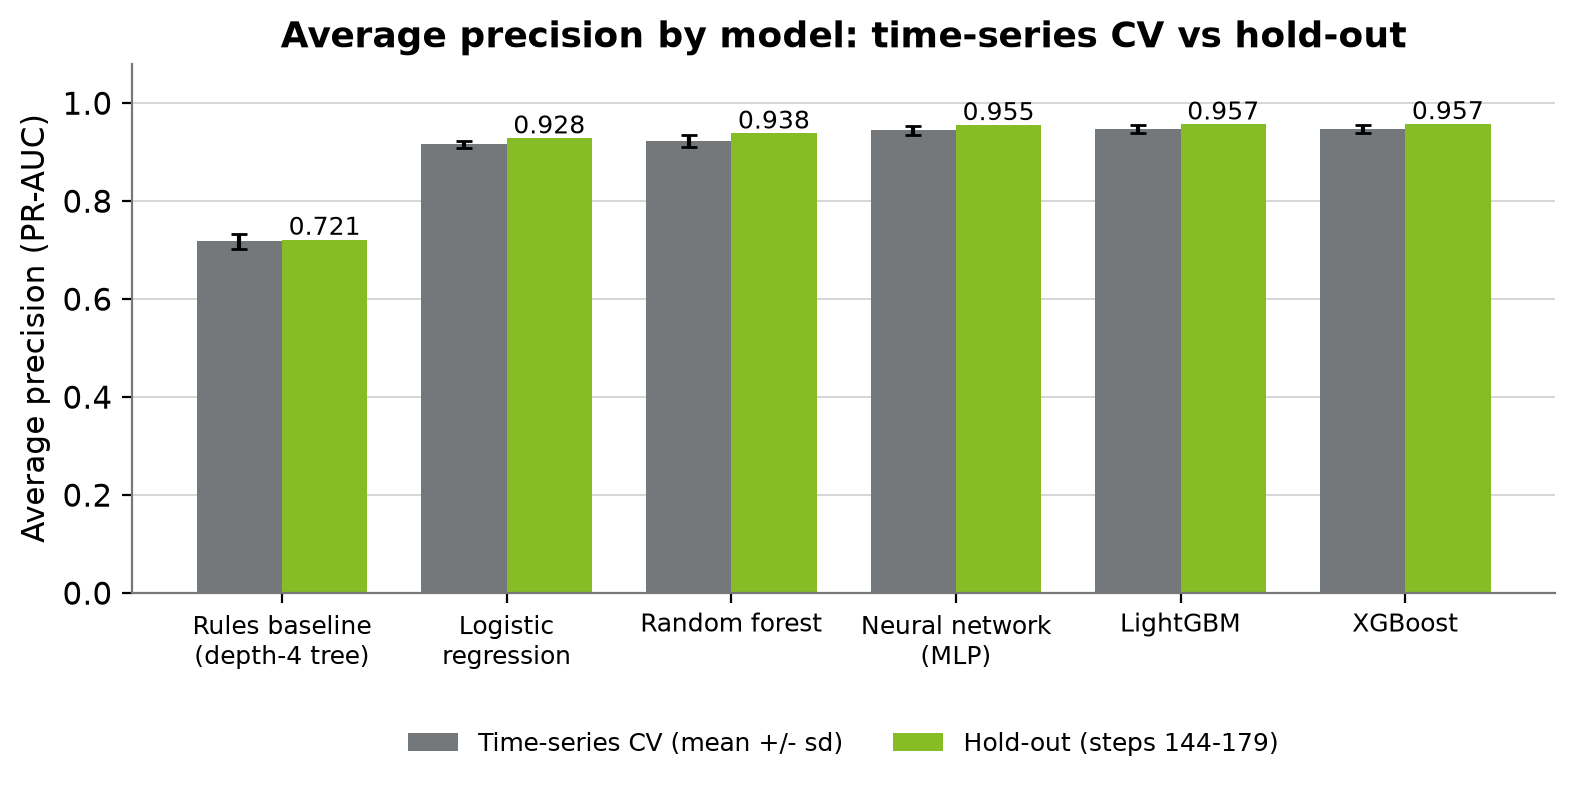

In [7]:
display(Image(FIG / "model_comparison.png"))

### Class-imbalance treatments

No treatment, class weights, random under-sampling (1:10) and SMOTE-NC (1:10), same booster, same validation fold. Resampling does not improve ranking and worsens calibration (Brier), which matters because the score feeds a cost-based threshold.

In [8]:
pd.DataFrame(R["imbalance"]).T[["average_precision", "roc_auc", "best_f1", "brier"]]

,average_precision,roc_auc,best_f1,brier
none,0.9571,0.9993,0.8918,0.0019
class_weight,0.9570,0.9992,0.8959,0.0025
undersample,0.9528,0.9992,0.8861,0.0039
smote,0.9546,0.9992,0.8903,0.0019


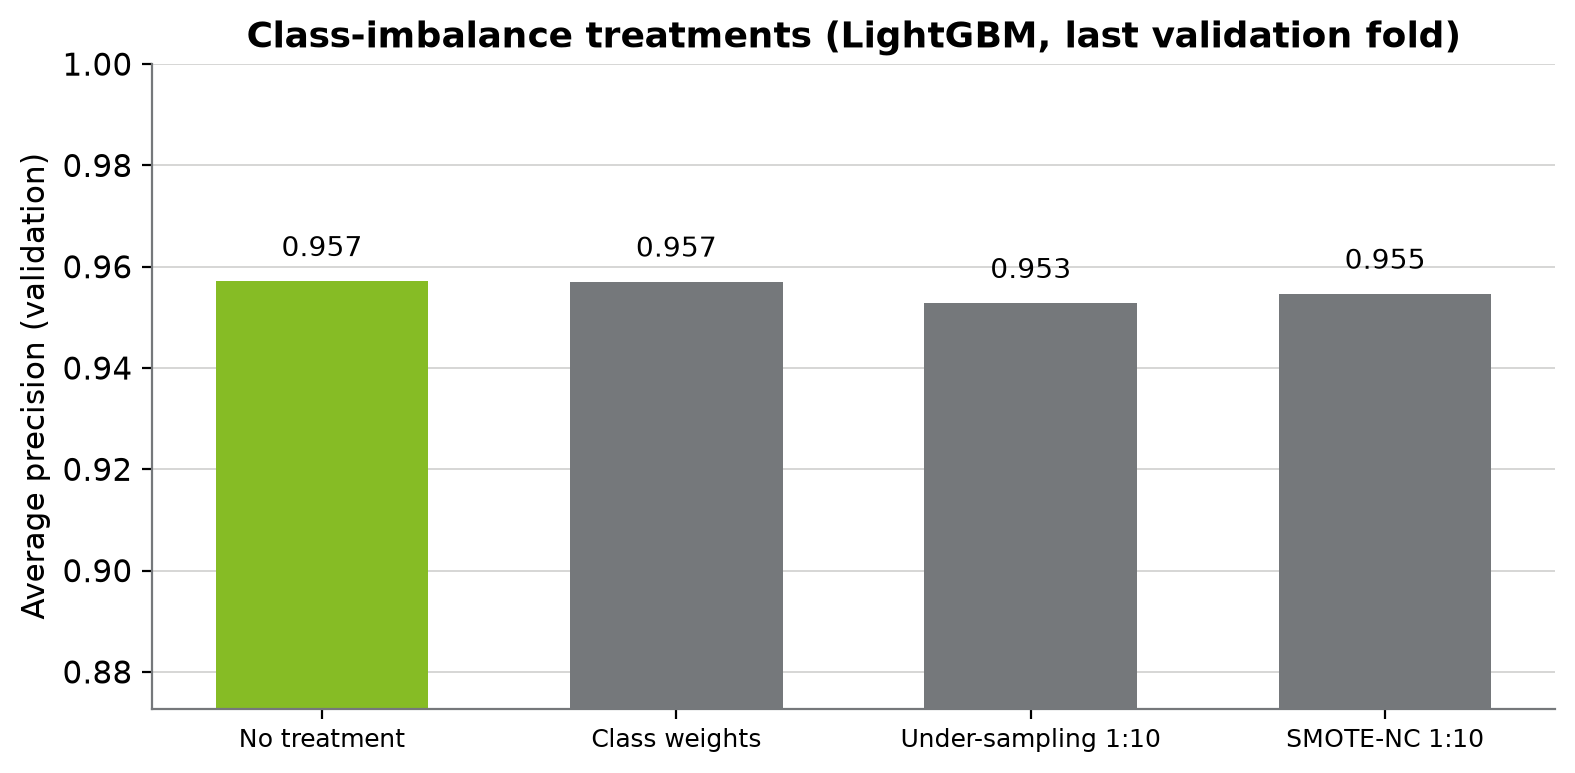

In [9]:
display(Image(FIG / "exp_imbalance_strategies.png"))

### Feature ablation

Raw fields only → raw + time-of-day → full minus time-of-day → full. Engineered history features drive the gain; time-of-day adds nothing.

In [10]:
pd.DataFrame(R["ablation"]).T[["n_features", "average_precision", "best_f1"]]

,n_features,average_precision,best_f1
Raw fields only,5.0000,0.9085,0.8333
Raw + time-of-day,7.0000,0.9083,0.8289
Full minus time-of-day,26.0000,0.9571,0.8931
Full feature set,28.0000,0.9575,0.8959


## 5. Tuning and the production candidate

Optuna searched the booster's main parameters with the same three time-ordered folds (objective: mean average precision). The production candidate is retrained on the whole training window without protected attributes.

In [11]:
if "tuning" in R:
    print("best CV average precision:", round(R["tuning"]["best_cv_average_precision"], 4), "over", R["tuning"]["n_trials"], "trials")
    display(pd.Series(R["tuning"]["best_params"]).to_frame("value"))
p = R["production"]
print(f"production: {p['name']} | features={len(p['features'])} | uses protected attributes={p['uses_protected_attributes']}")
pd.Series(p["test"]).to_frame("hold-out")

best CV average precision: 0.9524 over 25 trials


,value
learning_rate,0.1137
subsample,0.5446
colsample_bytree,0.8636
reg_lambda,26.9457
reg_alpha,0.0459
scale_pos_weight,1.8248
max_depth,7.0000
min_child_weight,1.0515
gamma,4.8519
n_estimators,900.0000


production: XGBoost | features=24 | uses protected attributes=False


,hold-out
roc_auc,0.9993
average_precision,0.9592
brier,0.0018
f1_at_0_5,0.8877
best_f1,0.8929
best_f1_threshold,0.6223
recall_at_top_0.5pct,0.4625
precision_at_top_0.5pct,1.0000
recall_at_top_1pct,0.8576
precision_at_top_1pct,0.9272


## 6. From score to decision: the operating point

Net benefit = fraud value stopped, minus 5 per alert and 10 per false positive, in the units of the amount column (illustrative). The threshold maximising it on validation is applied to the hold-out; a capacity-based alternative is shown for comparison.

In [12]:
d, dc = p["decision"], p["decision_capacity"]
pd.DataFrame({"max net benefit (chosen)": d, "fit analyst capacity": dc}).loc[["threshold", "alerts_per_step", "alert_rate", "precision", "recall", "false_positive_rate", "value_recall", "net_benefit_per_step"]]

,max net benefit (chosen),fit analyst capacity
threshold,0.1600,0.0800
alerts_per_step,50.1111,58.5278
alert_rate,0.0135,0.0158
precision,0.7511,0.6602
recall,0.9410,0.9660
false_positive_rate,0.0034,0.0054
value_recall,0.9914,0.9960
net_benefit_per_step,"19,874.5408","19,852.6325"


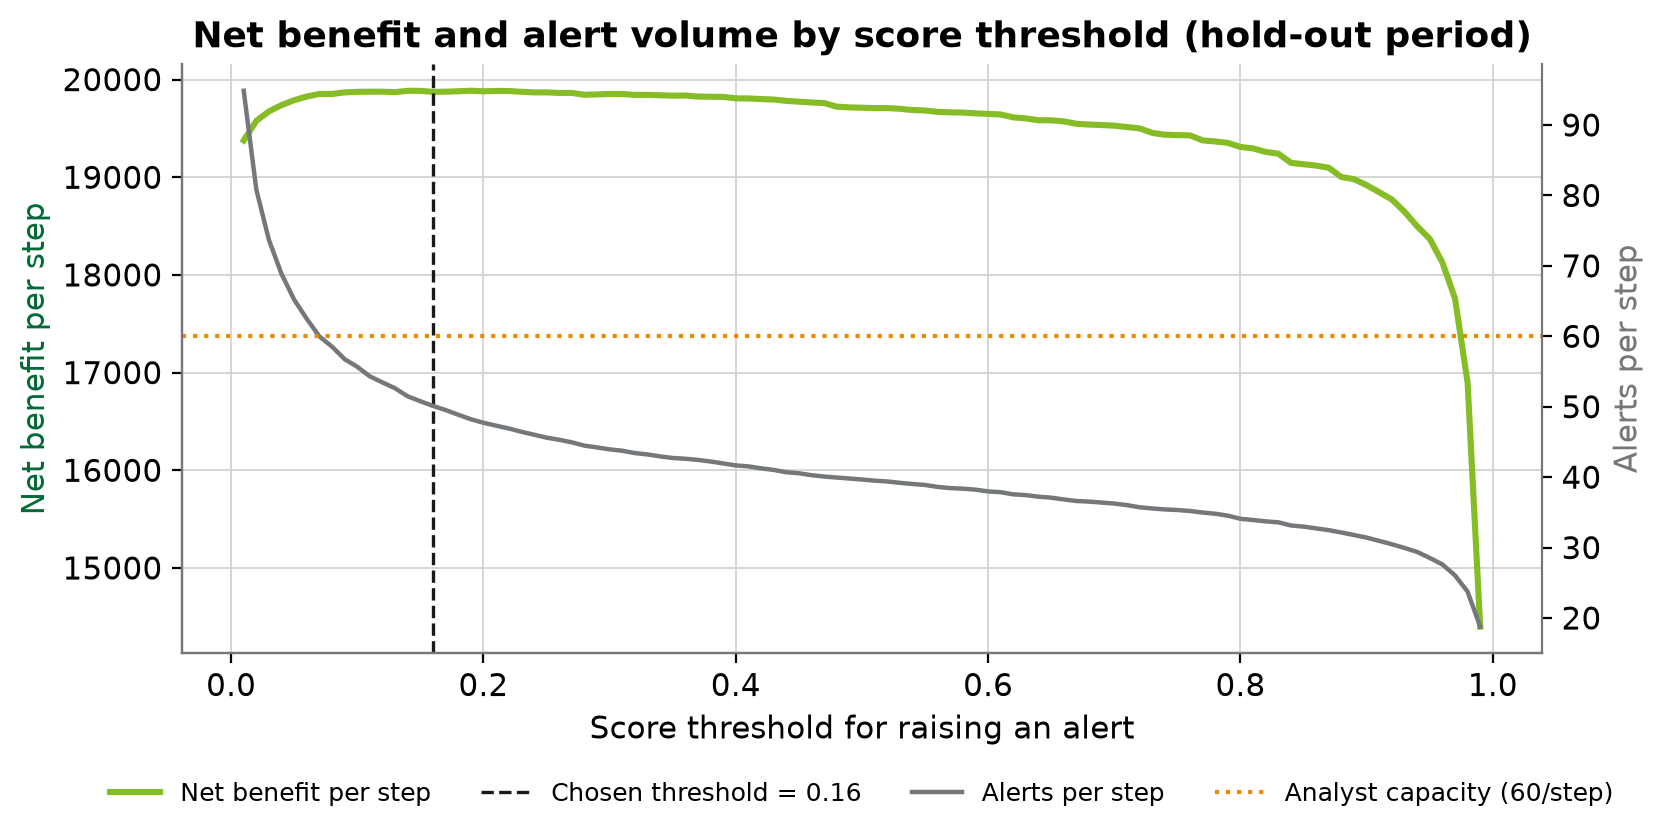

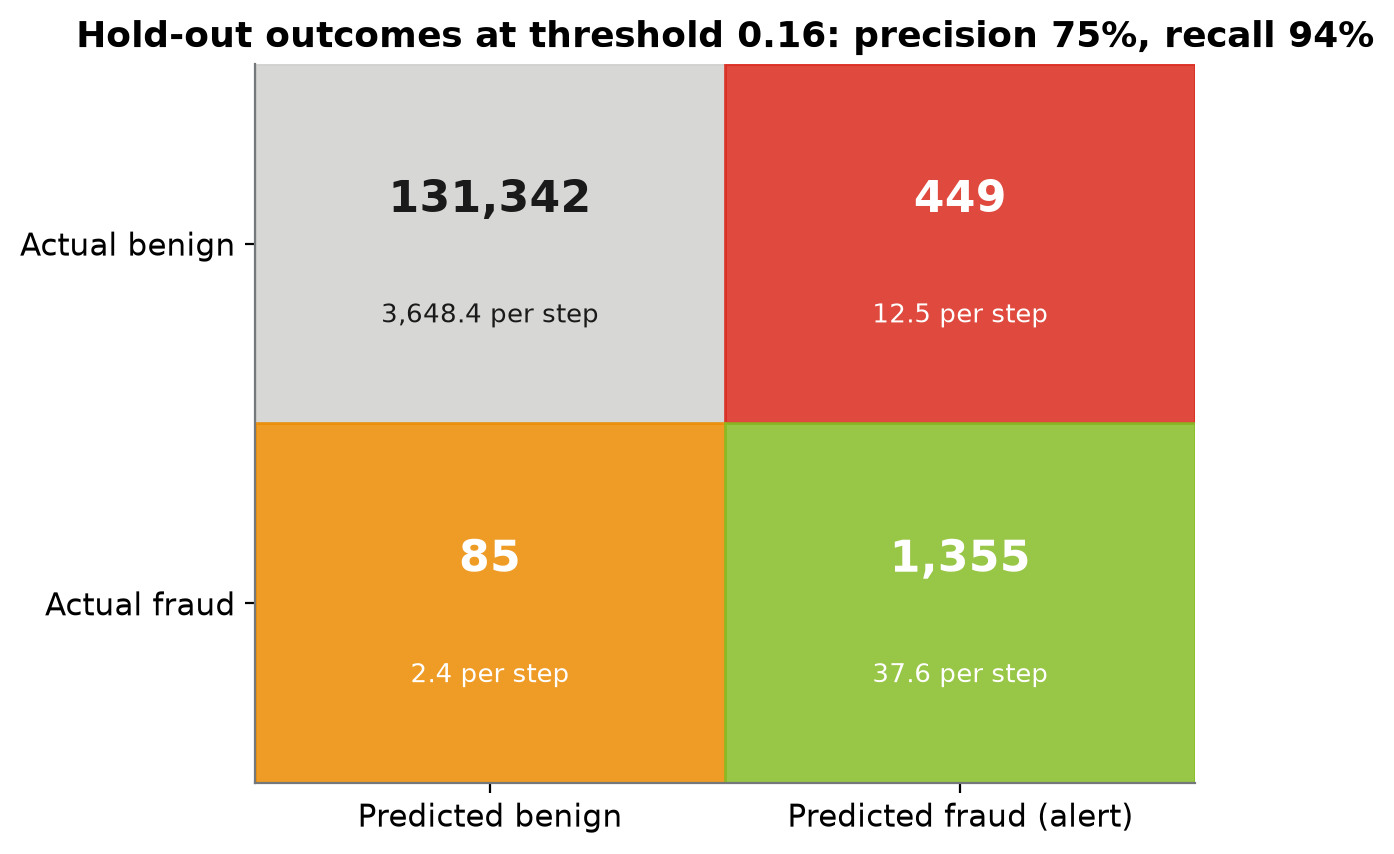

In [13]:
display(Image(FIG / "prod_cost_curve.png"))
display(Image(FIG / "prod_confusion.png"))

## 6b. Is it stable, and does the choice survive different cost assumptions?

Per-step precision and recall over the hold-out period, and the model-versus-rules comparison when the threshold is re-chosen on validation under different review and friction costs.

precision 0.65-0.85, recall 0.88-1.00, alert rate 1.19%-1.54% across 36 steps


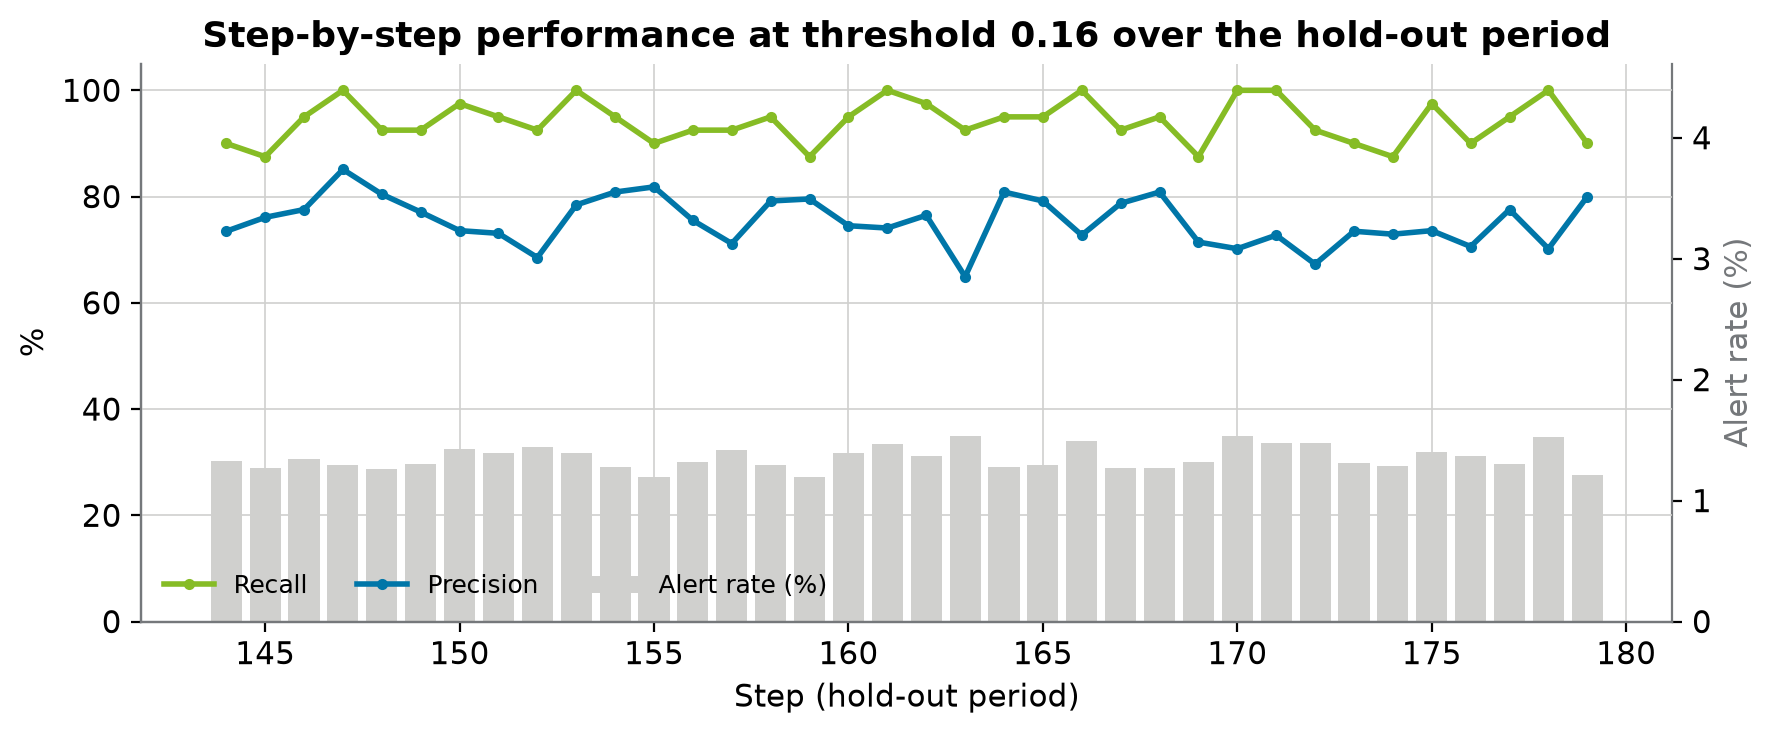

,review_cost,friction_cost,model_threshold,model_recall,model_alerts_per_step,model_net_benefit,rules_net_benefit
scenario,,,,,,,
base,5.0000,10.0000,0.1600,0.9410,50.1111,"715,483.4700","686,331.8900"
cheap review,2.0000,10.0000,0.1500,0.9437,50.7778,"721,327.0000","692,922.8900"
expensive review,15.0000,10.0000,0.2700,0.9208,44.9444,"698,906.0400","665,322.5700"
high friction,5.0000,50.0000,0.4800,0.8868,39.9444,"703,595.7100","652,905.8300"
"expensive review, high friction",15.0000,50.0000,0.4800,0.8868,39.9444,"689,215.7100","642,235.8300"


In [14]:
stab = pd.DataFrame(R["stability"])
print(f"precision {stab.precision.min():.2f}-{stab.precision.max():.2f}, recall {stab.recall.min():.2f}-{stab.recall.max():.2f}, alert rate {stab.alert_rate.min():.2%}-{stab.alert_rate.max():.2%} across {len(stab)} steps")
display(Image(FIG / "prod_stability.png"))
pd.DataFrame(R["cost_sensitivity"]).set_index("scenario")[["review_cost", "friction_cost", "model_threshold", "model_recall", "model_alerts_per_step", "model_net_benefit", "rules_net_benefit"]]

## 7. Why the split matters

The same model evaluated with a random stratified split versus the temporal hold-out. Here the random split is slightly *harder* (it scores early steps where customers have little history), and there is no drift to flatter it. Either way the split changes the answer, so it has to mirror how the model is used: forward in time.

In [15]:
if "random_split_comparison" in R:
    display(pd.Series(R["random_split_comparison"]).to_frame("average_precision"))

,average_precision
random_split_average_precision,0.9472
temporal_split_average_precision,0.9592
